In [21]:
import seaborn as sns
from sklearn.datasets import make_blobs

In [22]:
X,y = make_blobs(
    n_samples = 1000,
    n_features=2,
    centers=4,
    random_state=42
)

<Axes: >

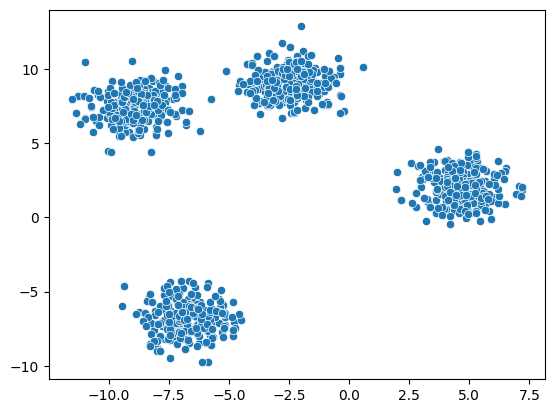

In [23]:
#visualize

sns.scatterplot(x=X[:,0],y=X[:,1])

In [24]:
#KMeans

from sklearn.cluster import KMeans
K=4

In [25]:
kmeans = KMeans(
    n_clusters=K,
    random_state=42
)

In [26]:
labels = kmeans.fit_predict(X)
# labels = cluster_number

<Axes: >

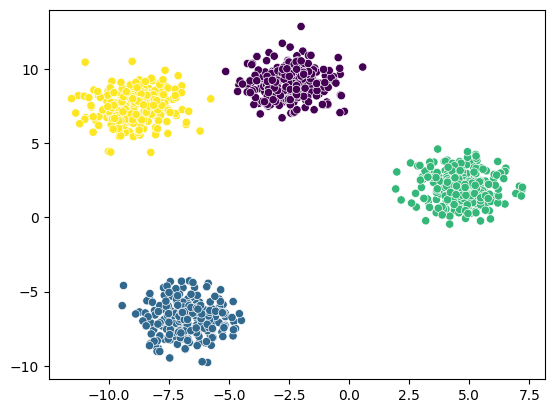

In [27]:
sns.scatterplot(x=X[:,0],y=X[:,1],c=labels)

# How to choose value of K ?

In [29]:
#Elbow method
wcss = []
for k in range(1,21):
  kmeans = KMeans(n_clusters=k)
  kmeans.fit_predict(X)
  wcss.append(kmeans.inertia_)

<Axes: >

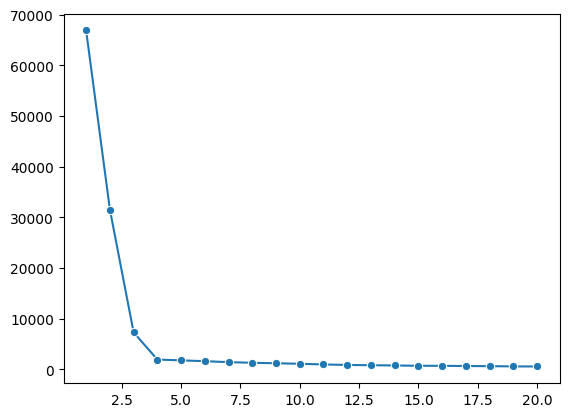

In [33]:
#Manual way of finding best k
sns.lineplot(x=range(1,21),y=wcss,marker='o')

In [34]:
#Automatic way of finding k
#Using Kneed module

!pip install kneed

In [36]:
from kneed import KneeLocator

knee = KneeLocator(range(1,21), wcss,curve='convex',direction='decreasing')

In [39]:
print("Optimal K is :",knee.knee)

Optimal K is : 4


In [42]:
#Silhouette Score

from sklearn.metrics import silhouette_score

ss = []

for k in range(2,21):
  kmeans = KMeans(n_clusters=k)
  labels = kmeans.fit_predict(X)
  ss.append(silhouette_score(X,labels))

<Axes: >

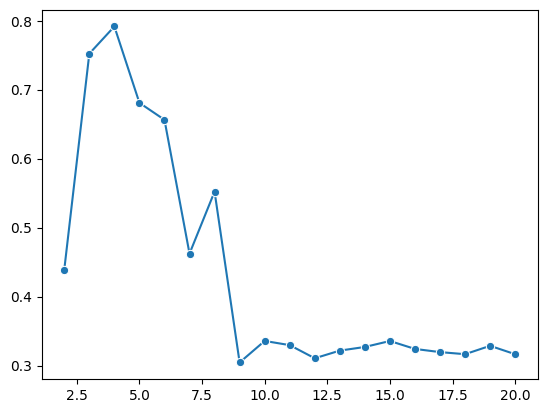

In [45]:
# plot of k vs ss

sns.lineplot(x=range(2,21),y=ss,marker='o')

In [ ]:
# Optimal K is 4